# Módulo 6 tarefa 3

#### 1) A base 'sinasc_RO_2019.csv' contém dados do sistema de nascidos vivos do DataSUS, cujo dicionário de dados está no arquivo 'Estrutura_SINASC_para_CD.pdf'. Carregue esse arquivo.

In [2]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



print("Pasta atual:")
print(os.getcwd())

print("\nArquivos aqui:")
print(os.listdir())

os.getcwd()
print(os.getcwd())


df = pd.read_csv('.ipynb_checkpoints/SINASC_RO_2019.csv')
df.head()

Pasta atual:
C:\Users\DELL\Documents\Hd-arquivos\cursos-e-pós\Curso-EBAC-cientista-de-Dados\EBAC-Cientista-de-dados\Curso\projetos\parte-07-descritivas-I\tarefa-03

Arquivos aqui:
['.ipynb_checkpoints', 'mod06 aula05 Gráfico de barras com duas entradas.ipynb', 'mod06 Tarefa 3.ipynb', 'Profissão Cientista de Dados M6 A5.zip', 'Profissão Cientista de Dados M6 Pratique 3.zip', 'resolvendo-tarefa-03-fazendo.ipynb']
C:\Users\DELL\Documents\Hd-arquivos\cursos-e-pós\Curso-EBAC-cientista-de-Dados\EBAC-Cientista-de-dados\Curso\projetos\parte-07-descritivas-I\tarefa-03


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


#### 2) Categorize a variável APGAR5 conforme as seguintes quebras:

- 0 a 3: 'asfixia grave'
- 4 a 5: 'asfixia moderada'
- 6 a 7: 'asfixia leve'
- 8 a 10: 'normal'

REsolvendo tarefa 3 - exercicio 2

In [4]:


# 2) categorizar APGAR5
df['APGAR5_CAT'] = pd.cut(
    df['APGAR5'],
    bins=[-1, 3, 5, 7, 10],
    labels=['asfixia grave', 'asfixia moderada', 'asfixia leve', 'normal']
)

# conferir
df[['APGAR5', 'APGAR5_CAT']].head()

,APGAR5,APGAR5_CAT
0,10.0,normal
1,9.0,normal
2,10.0,normal
3,10.0,normal
4,10.0,normal


#### 3) Monte um gráfico comparando a distribuição de APGAR5 por sexo para cada grupo de tempo de gestação (GESTACAO).

Resolvendo tarefa 3 - Exercicio 3

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


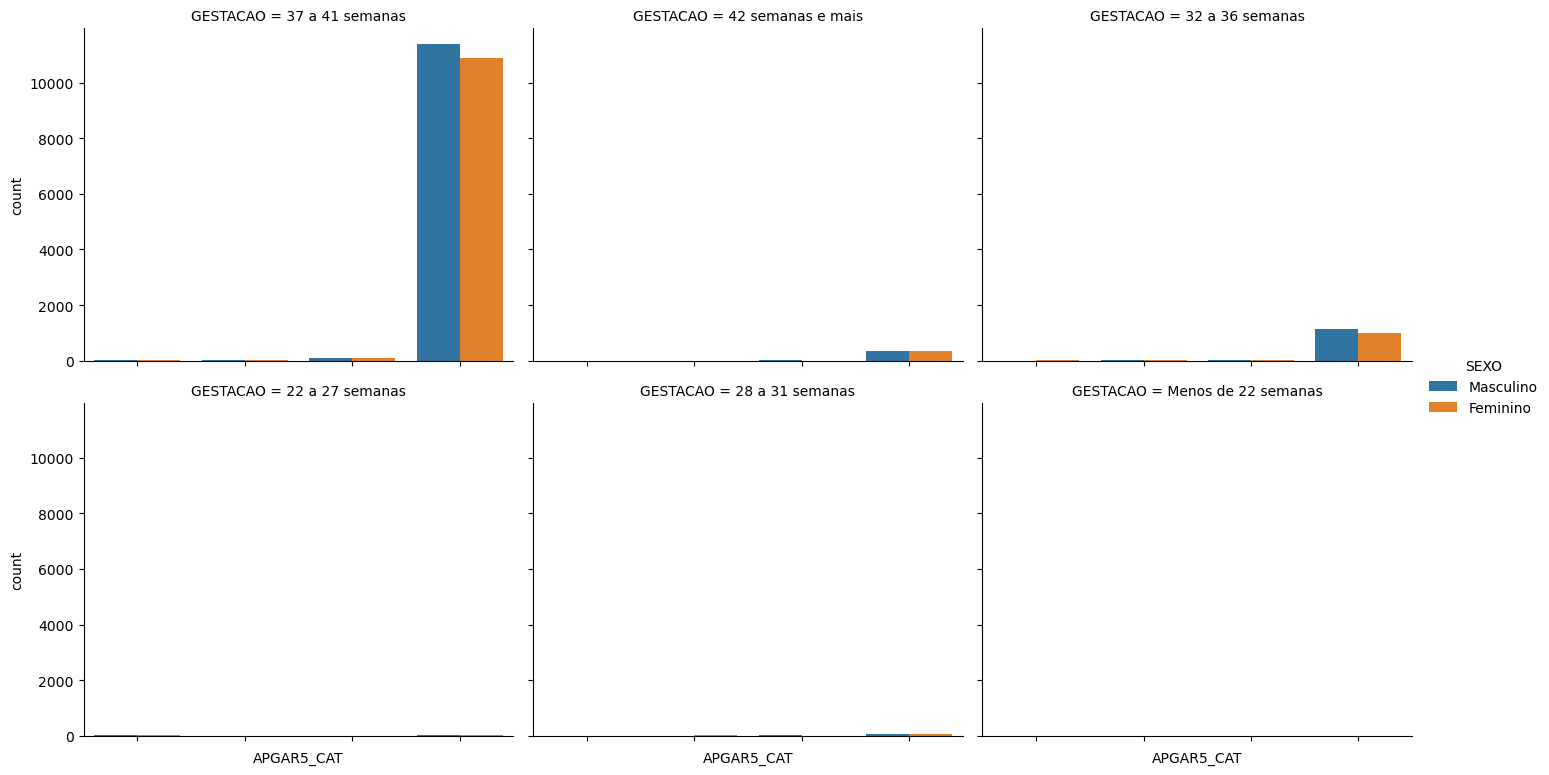

In [5]:
g = sns.catplot(
    data=df,
    x='APGAR5_CAT',
    hue='SEXO',
    col='GESTACAO',
    kind='count',
    col_wrap=3,
    height=4,
    aspect=1.2
)

g.set_xticklabels(rotation=45)
plt.show()

####  4) Monte uma tabela cruzada com APGAR5 nas colunas e GESTACAO nas linhas

Resolvendo tarefa 3 - exercicio 4

In [6]:
tab_cruzada = pd.crosstab(df['GESTACAO'], df['APGAR5_CAT'])
tab_cruzada

APGAR5_CAT,asfixia grave,asfixia moderada,asfixia leve,normal
GESTACAO,,,,
22 a 27 semanas,21,1,12,51
28 a 31 semanas,3,12,18,129
32 a 36 semanas,8,19,73,2134
37 a 41 semanas,33,28,196,22266
42 semanas e mais,1,1,6,690
Menos de 22 semanas,2,0,1,4


####  5) Da tabela cruzada do intem anterior, calcule os percentuais de linha. Ou seja, a distribuição da variável APGAR5 para cada classe de GESTACAO dado.

REsolvendo tarefa 3 - exercicio 5

In [7]:
tab_pct_linha = tab_cruzada.div(tab_cruzada.sum(axis=1), axis=0) * 100
tab_pct_linha.round(2)

APGAR5_CAT,asfixia grave,asfixia moderada,asfixia leve,normal
GESTACAO,,,,
22 a 27 semanas,24.71,1.18,14.12,60.00
28 a 31 semanas,1.85,7.41,11.11,79.63
32 a 36 semanas,0.36,0.85,3.27,95.52
37 a 41 semanas,0.15,0.12,0.87,98.86
42 semanas e mais,0.14,0.14,0.86,98.85
Menos de 22 semanas,28.57,0.00,14.29,57.14


####  6) Os médicos costumam classificar parto prematuro quando a gestação tem menos que 37 semanas. Faça um gráfico de barras da tabela cruzada acima e conclua se você acha que este conjunto de dados corrobora ou não com a afirmação dos médicos.

REsolvendo tarefa 3 - exercicio 6

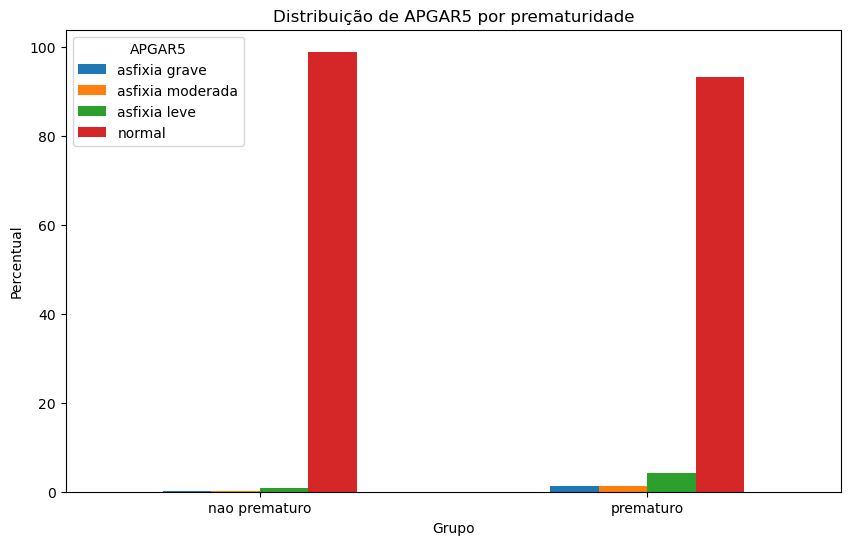

In [8]:
df['PREMATURO'] = df['GESTACAO'].apply(
    lambda x: 'prematuro' if x in ['Menos de 22 semanas', '22 a 27 semanas', '28 a 31 semanas', '32 a 36 semanas']
    else ('nao prematuro' if pd.notna(x) else pd.NA)
)

tab_prematuro = pd.crosstab(df['PREMATURO'], df['APGAR5_CAT'])
tab_prematuro_pct = tab_prematuro.div(tab_prematuro.sum(axis=1), axis=0) * 100

tab_prematuro_pct.plot.bar(figsize=(10,6))
plt.title('Distribuição de APGAR5 por prematuridade')
plt.ylabel('Percentual')
plt.xlabel('Grupo')
plt.xticks(rotation=0)
plt.legend(title='APGAR5')
plt.show()

#### 7) Veja se há relação entre APGAR5 e o peso do bebê. Isso pode ser feito de diversas formas. Fique à vontade para escolher a melhor maneira na sua opinião, ou até testar mais de um dos gráficos que vimos. Fique à vontade também para consultar a documentação e utilizar algum outro recurso se achar conveniente.

REsolvendo tarefa 3 - Exefcicio 7

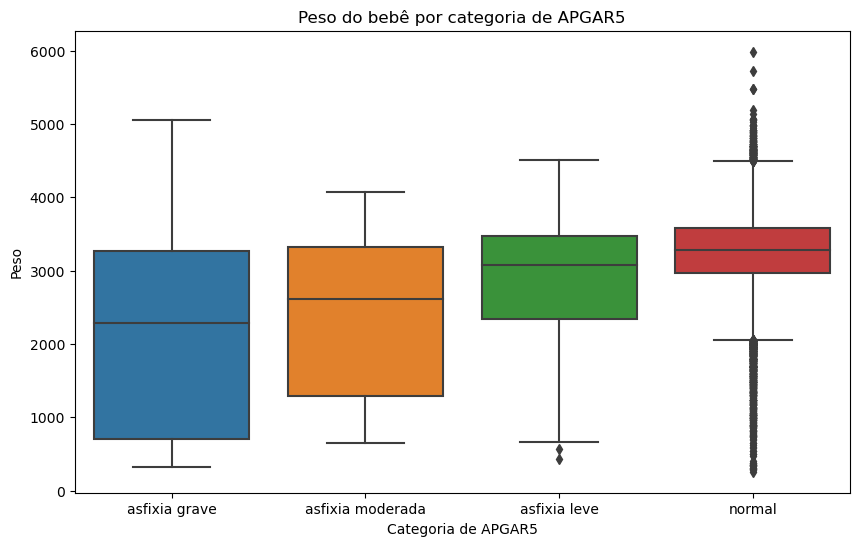

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x='APGAR5_CAT', y='PESO', data=df)
plt.title('Peso do bebê por categoria de APGAR5')
plt.xlabel('Categoria de APGAR5')
plt.ylabel('Peso')
plt.show()